In [1]:
from striprtf.striprtf import rtf_to_text
import pandas as pd
import os
import re

os.chdir("/Users/Yannick/Documents/PhD/text_mining/geothermal")


In [2]:
def load_all_rtf_articles(directory):
    all_articles = []

    # Loop through all .rtf files
    for filename in os.listdir(directory):
        if not filename.lower().endswith(".rtf"):
            continue  # skip non-RTF files

        file_path = os.path.join(directory, filename)

        # Read file
        with open(file_path, "r", encoding="utf-8") as file:
            rtf_content = file.read()

        # Convert RTF → text
        plain_text = rtf_to_text(rtf_content)

        # Split into articles
        articles = plain_text.split("End of Document")

        # Extract data from each article
        for article in articles:
            if not article.strip():
                continue

            title = re.search(r'^(.*?)\n', article)
            newspaper = re.search(r'\n(.*?)\n\d{1,2} .*? \d{4}', article)
            date = re.search(r'\n(\d{1,2} .*? \d{4})', article)
            section = re.search(r'Section:\s*(.*?);', article)
            word_count = re.search(r'Length:\s*(\d+)', article)
            load_date = re.search(r'Load-Date:\s*(.*)', article)
            body = re.search(
                r'Body\n\n(.*?)\n\n(?:Load-Date:|Copyright|End of Document)',
                article,
                re.DOTALL
            )

            all_articles.append({
                'source_file': filename,
                'title': title.group(1).strip() if title else '',
                'newspaper': newspaper.group(1).strip() if newspaper else '',
                'date': date.group(1).strip() if date else '',
                'section': section.group(1).strip() if section else '',
                'word_count': int(word_count.group(1)) if word_count else None,
                'body': body.group(1).strip() if body else '',
                'load_date': load_date.group(1).strip() if load_date else ''
            })

    # Convert to DataFrame
    return pd.DataFrame(all_articles)


# ---- Run the function ----
df = load_all_rtf_articles("input_data")

# Inspect the first rows
print(df.head(10))
print(f"\nLoaded {len(df)} articles from folder.")


               source_file title                      newspaper  \
0  Bestanden (500) (3).RTF                         Nieuwe Oogst   
1  Bestanden (500) (3).RTF                         Nieuwe Oogst   
2  Bestanden (500) (3).RTF                      De Gelderlander   
3  Bestanden (500) (3).RTF                                Trouw   
4  Bestanden (500) (3).RTF                             Trouw.nl   
5  Bestanden (500) (3).RTF                  AD/Haagsche Courant   
6  Bestanden (500) (3).RTF                  AD/Haagsche Courant   
7  Bestanden (500) (3).RTF                Noordhollands Dagblad   
8  Bestanden (500) (3).RTF        De Twentsche Courant Tubantia   
9  Bestanden (500) (3).RTF                        De Stentor.nl   

               date           section  word_count  \
0  24 augustus 2019                           483   
1  24 augustus 2019                           123   
2  26 augustus 2019   De Gelderlander         293   
3  26 augustus 2019           Vandaag         832 

In [6]:
# find unique newspapers in the dataset
unique_newspapers = df['newspaper'].explode().unique()
print("Unique newspapers in dataset:", unique_newspapers)

Unique newspapers in dataset: ['Leeuwarder Courant' 'Boerderij Vandaag' 'Reformatorisch Dagblad'
 'De Stentor / Dagblad Flevoland' '' 'Noordhollands Dagblad'
 'de Volkskrant' 'Brabants Dagblad' 'NRC Handelsblad' 'De Gelderlander'
 'Provinciale Zeeuwse Courant' 'De Stentor / Zwolse Courant'
 'De Twentsche Courant Tubantia' 'De Stentor / Nieuw Kamper Dagblad'
 'De Stentor / Gelders Dagblad' 'De Stentor / Sallands Dagblad'
 'BN/DeStem' 'De Stentor / Zutphens Dagblad' 'De Stentor / Veluws Dagblad'
 'De Stentor/ Deventer Dagblad' 'De Stentor / Apeldoornse Courant'
 'Eindhovens Dagblad' 'Leidsch Dagblad' 'IJmuider Courant'
 'Haarlems Dagblad' 'De Gooi- en Eemlander' 'AD/Haagsche Courant' 'Trouw'
 'Dagblad van het Noorden' 'NRC.NEXT' 'Cobouw' 'De Telegraaf' 'Het Parool'
 'AD/Algemeen Dagblad' 'Nederlands Dagblad' 'AD/Groene Hart'
 'AD/De Dordtenaar' 'Huis aan Huis' 'De Krant' 'Limburgs Dagblad'
 'De Limburger' 'De Stentor' 'De Peperbus' 'Stadsblad Noord-Midden'
 'AD/Utrechts Nieuwsblad' 'AD/R

In [3]:
# -------------------------------------------------------
# 1. FILTER OUT MISSING NEWSPAPER + MISSING DATE
# -------------------------------------------------------

missing_newspaper = df[df['newspaper'].isna() | (df['newspaper'].str.strip() == "")]
print("Number of missing newspapers:", len(missing_newspaper))

missing_dates = df[df['date'].isna() | (df['date'].str.strip() == "")]
print("Number of missing dates:", len(missing_dates))

# Remove rows missing newspaper or date
df_cleaned = df[
    ~(df['newspaper'].isna() | (df['newspaper'].str.strip() == ""))
].copy()

df_cleaned = df_cleaned[
    ~(df_cleaned['date'].isna() | (df_cleaned['date'].str.strip() == ""))
].copy()

df_cleaned = df_cleaned.reset_index(drop=True)

print("Rows after filtering missing data:", len(df_cleaned))

# -------------------------------------------------------
# 2. DUTCH → ENGLISH MONTH CLEANING + DATE PARSING
# -------------------------------------------------------

month_map = {
    "januari": "January",
    "februari": "February",
    "maart": "March",
    "april": "April",
    "mei": "May",
    "juni": "June",
    "juli": "July",
    "augustus": "August",
    "september": "September",
    "oktober": "October",
    "november": "November",
    "december": "December"
}

def dutch_to_english_month(date_str: str) -> str:
    if pd.isna(date_str):
        return date_str
    s = str(date_str).lower()
    for nl, en in month_map.items():
        s = re.sub(rf"\b{nl}\b", en, s)
    return s

df_cleaned["date_str_clean"] = df_cleaned["date"].astype(str).apply(dutch_to_english_month)

df_cleaned["date_dt"] = pd.to_datetime(
    df_cleaned["date_str_clean"],
    dayfirst=True,
    errors="coerce"
)

print("Total rows:", len(df_cleaned))
print("NaT after parsing:", df_cleaned["date_dt"].isna().sum())

df_cleaned["date"] = df_cleaned["date_dt"]

# -------------------------------------------------------
# 3. DEDUPLICATE ON 'body' & COLLAPSE OTHER COLUMNS TO SETS
# -------------------------------------------------------

# Identify all columns except body
other_cols = [c for c in df_cleaned.columns if c != "body"]

def collapse_dates(series):
    """Return earliest parsed timestamp."""
    cleaned = series.dropna()
    if len(cleaned) == 0:
        return pd.NaT
    return cleaned.min()

def collapse_to_set(series):
    """Return unique values as a set."""
    return set(series.dropna().unique())

agg_dict = {}
for col in other_cols:
    if col == "date":
        agg_dict[col] = collapse_dates      # KEEP EARLIEST DATE
    else:
        agg_dict[col] = collapse_to_set     # EVERYTHING ELSE → set()

df_cleaned = (
    df_cleaned
    .groupby("body", as_index=False)
    .agg(agg_dict)
)

print("Rows after deduplicating on body:", len(df_cleaned))

# -------------------------------------------------------
# 4. WORD COUNT COLUMN (using 'body')
# -------------------------------------------------------

df_cleaned["word_count"] = (
    df_cleaned["body"]
    .astype(str)
    .str.split()
    .str.len()
)

# Inspect word count stats if needed
#print("\nWord count stats:")
#print(df_cleaned["word_count"].describe())


# -------------------------------------------------------
# 5. GEOTHERMAL KEYWORD DETECTION
# -------------------------------------------------------

geo_keywords = [
    r"aardwarmte\w*",     # aardwarmte*
    r"geotherm\w*",       # geotherm*
]

geo_pattern = r"\b(" + "|".join(geo_keywords) + r")\b"

df_cleaned["geo_hits"] = (
    df_cleaned["body"]
    .astype(str)
    .str.lower()
    .str.count(geo_pattern)
)

# Inspect geothermal hits distribution if needed
#print("\nDistribution of geothermal keyword hits:")
#print(df_cleaned["geo_hits"].value_counts().sort_index())

# -------------------------------------------------------
# 6. FILTERING — ADJUST THESE TWO THRESHOLDS
# -------------------------------------------------------

MIN_WORDS = 100      # Recommended starting value — inspect and adjust
MIN_GEO_HITS = 3     # Recommended starting value — stricter = more relevant corpus

df_final = df_cleaned[
    (df_cleaned["word_count"] >= MIN_WORDS) &
    (df_cleaned["geo_hits"] >= MIN_GEO_HITS)
].reset_index(drop=True)

print("\nNumber of documents after relevance filtering:", len(df_final))


# -------------------------------------------------------
# 7. FINAL DUPLICATE / MISSING CHECKS
# -------------------------------------------------------

df_final_hashable = df_final.copy()

for col in df_final_hashable.columns:
    df_final_hashable[col] = df_final_hashable[col].apply(
        lambda x: frozenset(x) if isinstance(x, set) else x
    )

duplicate_rows = df_final_hashable[df_final_hashable.duplicated()]
print("Full-row duplicates:", len(duplicate_rows))

missing_newspaper = df_final[df_final['newspaper'].isna() | (df_final['newspaper'].str.strip() == "")]
print("Missing newspapers after all cleaning:", len(missing_newspaper))

print("\nFINAL DOCUMENT COUNT:", len(df_final))

# -------------------------------------------------------
# 8. LANGUAGE DETECTION
# -------------------------------------------------------

from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

# Function to safely detect language
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

# Apply to the body column (you can also use 'title' or combine both)
df_final['language'] = df_final['body'].apply(detect_language)

# Count language occurrences
print("Percentage Dutch documents:", df_final[['language']].value_counts()/len(df_final) * 100)

print("\nSample of final dataset:")
print(df_final.head(5))


Number of missing newspapers: 165
Number of missing dates: 165
Rows after filtering missing data: 4996
Total rows: 4996
NaT after parsing: 0
Rows after deduplicating on body: 3601

Number of documents after relevance filtering: 1392
Full-row duplicates: 0
Missing newspapers after all cleaning: 0

FINAL DOCUMENT COUNT: 1392
Percentage Dutch documents: language
nl          100.0
Name: count, dtype: float64

Sample of final dataset:
                                                body  \
0  "Door dit faillissement is het project af van ...   
1  'Als dit project nu niet lukt, moeten we op zo...   
2  'Antwoorden ontbreken nog steeds, we kiezen nu...   
3  'Coating van leidingen niet afdoende'\nAbdel I...   
4  'Dit is een postzegel binnen de bebouwde kom v...   

                  source_file title              newspaper       date  \
0  {Bestanden (501-1000).RTF}    {}               {Cobouw} 2013-07-30   
1   {Bestanden (500) (1).RTF}    {}   {Leeuwarder Courant} 2021-10-16   
2     {Bes

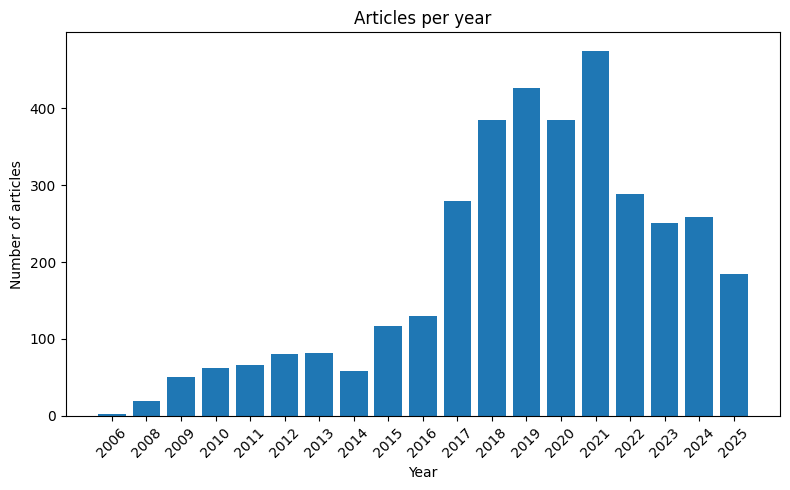

In [4]:
import matplotlib.pyplot as plt

# Extract year from data and turn into integer
df_cleaned['year'] = df_cleaned['date'].dt.year

# Count articles per year
articles_per_year = df_cleaned['year'].value_counts().sort_index()

# Plot: articles per year
plt.figure(figsize=(8, 5))
plt.bar(articles_per_year.index.astype(str), articles_per_year.values)
plt.xlabel("Year")
plt.ylabel("Number of articles")
plt.title("Articles per year")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("output/figures/descriptive_stats/articles_over_time.png", dpi=300)


Top 10 newspapers by number of articles:
newspaper
Dagblad van het Noorden          125
AD/Haagsche Courant               87
Noordhollands Dagblad             66
Leeuwarder Courant                54
De Limburger                      54
Eindhovens Dagblad                40
De Gelderlander                   40
Brabants Dagblad                  40
De Twentsche Courant Tubantia     37
Nieuwe Oogst                      36
Name: count, dtype: int64


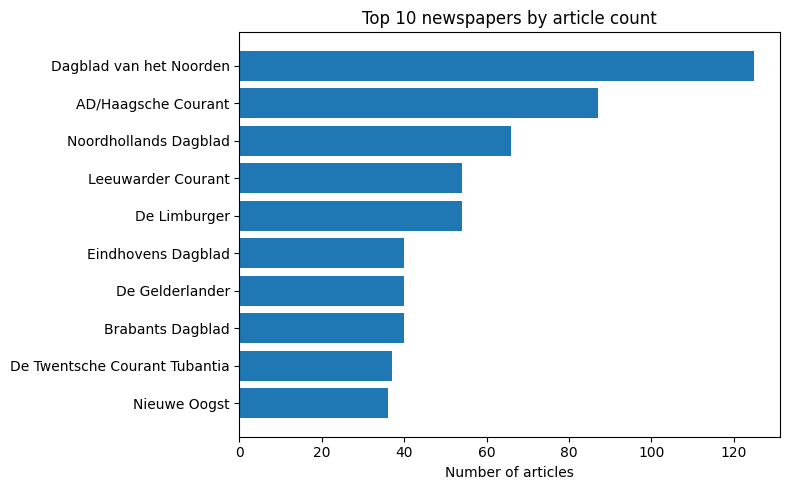

In [5]:
# Expand the set-valued newspaper column into long format
newspapers_long = (
    df_final['newspaper']
    .apply(lambda x: list(x) if isinstance(x, set) else [])
    .explode()
)

# Then count occurrences
newspaper_counts = newspapers_long.value_counts()

print("Top 10 newspapers by number of articles:")
print(newspaper_counts.head(10))


# Plot: top N newspapers
top_n = 10  # change this if you want more/less
top_newspapers = newspaper_counts.head(top_n)

plt.figure(figsize=(8, 5))
plt.barh(top_newspapers.index, top_newspapers.values)
plt.xlabel("Number of articles")
plt.title(f"Top {top_n} newspapers by article count")
plt.gca().invert_yaxis()  # so the highest is on top
plt.tight_layout()

plt.savefig("output/figures/descriptive_stats/top_newspapers.png", dpi=300)


In [6]:
# Download nlp pipeline
import torch.version
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline
import torch

tokenizer = AutoTokenizer.from_pretrained("Babelscape/wikineural-multilingual-ner")
model = AutoModelForTokenClassification.from_pretrained("Babelscape/wikineural-multilingual-ner")

nlp = pipeline("ner", model=model, tokenizer=tokenizer, grouped_entities=True)


/Users/Yannick/anaconda3/envs/bertopic311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps:0
/Users/Yannick/anaconda3/envs/bertopic311/lib/python3.11/site-packages/transformers/pipelines/token_classification.py:186: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="AggregationStrategy.SIMPLE"` instead.
  warnings.warn(


In [7]:
# -------------------------------------------------------
# 9. NER EXTRACTION
# -------------------------------------------------------

# Initialize lists to store the extracted entities
locations = []
persons = []
organizations = []

# Iterate over the DataFrame rows
for _, row in df_final.iterrows():
    corpus = row['body']
    nlp_result = nlp(corpus)
    
    # Initialize lists to store the entities
    locs = []
    pers = []
    orgs = []
    
    # Extract the entities from the NLP result
    for entity in nlp_result:
        entity_group = entity['entity_group']
        
        if entity_group == 'LOC':
            locs.append(entity['word'])
        elif entity_group == 'PER':
            pers.append(entity['word'])
        elif entity_group == 'ORG':
            orgs.append(entity['word'])
    
    locs = set(locs)
    pers = set(pers)
    orgs = set(orgs) 

    # Append the extracted entities to their respective lists
    locations.append(locs)
    persons.append(pers)
    organizations.append(orgs)

# Add the new columns to the DataFrame
df_final['locations'] = locations
df_final['persons'] = persons
df_final['organizations'] = organizations

# Show the updated DataFrame
print(df_final[['locations', 'persons', 'organizations']].head())

df_final.to_csv('output/text/dataframe_NER.csv')

                                           locations  \
0                                         {Den Haag}   
1  {Den Haag, Triangel, Julianalaan, Warmte van L...   
2                {Leeuwarden, Leeuwarder, ##uwarden}   
3  {Haag, Den Haag, Haga Ziekenhuis, Leyweg, Fran...   
4  {Den Haag, Haag, Den Haag Zuidwest, Meppelweg,...   

                                             persons  \
0                {Van Heekeren, Victor van Heekeren}   
1                            {Gert Schurer, Schurer}   
2  {Rob Jetten, Gert Schurer, Jetten, Debbie Zwee...   
3         {Jan Willem Rösingh, Abdel Ilah Rubio Den}   
4                     {René Oudshoorn, Tanja Verkai}   

                                       organizations  
0                              {Platform Geothermie}  
1      {Friesland College, Geocombinatie Leeuwarden}  
2       {PGGM, Tweede Kamer, Veolia, Warmte van Lee}  
3                                                 {}  
4  {Hart voor Den Haag, Nota Externe Veiligheid, ..

In [64]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from umap import UMAP
from hdbscan import HDBSCAN
import spacy

# ----------------------------------------------------
# 1. Prepare documents and timestamps
# ----------------------------------------------------
# Make sure date is datetime
df_final['date'] = pd.to_datetime(df_final['date'], errors='coerce')

# Load Dutch spaCy model for lemmatization
nlp = spacy.load("nl_core_news_lg", disable=["ner", "parser"])  

# Lemmatization function
def lemmatize_dutch(text):
    doc = nlp(text.lower())
    lemmas = []
    for token in doc:
        # Remove punctuation, spaces, numbers, URL tokens, etc.
        if token.is_punct or token.is_space or token.like_num or token.like_url or token.like_email:
            continue

        lemma = token.lemma_.strip()

        # Skip empty lemma or weird residues
        if not lemma or len(lemma) <= 1:
            continue

        lemmas.append(lemma)

    return " ".join(lemmas)

# Apply lemmatization to the 'body' column
df_final["body_lemma"] = df_final["body"].astype(str).apply(lemmatize_dutch)

# Prepare documents and timestamps
docs = df_final["body_lemma"].tolist()
timestamps = df_final['date'].tolist()  # used for topics_over_time

# ----------------------------------------------------
# 2. Dutch stopwords (your existing file)
# ----------------------------------------------------
stopwords = pd.read_table('stopwords_nl.txt', header=None)[0].tolist()
domain_stopwords = pd.read_table('domain_stopwords_nl.txt', header=None)[0].tolist()

stopwords = stopwords + domain_stopwords


vectorizer_model = CountVectorizer(
    stop_words=stopwords,
    min_df=2,              # a bit higher to avoid very rare noise terms
    ngram_range=(1, 2)     # unigrams + bigrams for richer topic labels
)

# ----------------------------------------------------
# 3. Embedding model (modern multilingual, good for Dutch)
# ----------------------------------------------------
# This is still one of the top general-purpose multilingual models.
embed_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
)

# ----------------------------------------------------
# 4. Dimensionality reduction (UMAP)
# ----------------------------------------------------
umap_model = UMAP(
    n_neighbors=30,     # set iteratively to ensure a good number of topics that are seperated
    n_components=5,     
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# ----------------------------------------------------
# 5. Clustering (HDBSCAN)
# ----------------------------------------------------
hdbscan_model = HDBSCAN(
    min_cluster_size=6,        # set iteratively to ensure a good number of topics that are separated
    min_samples=8,         # lower -> more clusters, higher -> fewer
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# ----------------------------------------------------
# 6. Topic representation (how topics are labeled)
# ----------------------------------------------------
keybert_model = KeyBERTInspired()
mmr_model = MaximalMarginalRelevance(diversity=0.3)

representation_model = {
    "KeyBERTInspired": keybert_model,
    "MMR": mmr_model,
}

# ----------------------------------------------------
# 7. Build BERTopic model
# ----------------------------------------------------
topic_model = BERTopic(
    embedding_model=embed_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    top_n_words=15,              
    calculate_probabilities=True,
    verbose=True
)

# ----------------------------------------------------
# 8. Fit the model
# ----------------------------------------------------
topics, probs = topic_model.fit_transform(docs)


# Get general topic info (includes topic IDs, sizes, etc.)
topic_info = topic_model.get_topic_info()

# Option 1: exclude the outlier topic -1
topic_ids = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()

# If you DO want to include -1, just use:
# topic_ids = topic_info["Topic"].tolist()

rows = []

for topic_id in topic_ids:
    # get_topic returns list of (word, score)
    words_scores = topic_model.get_topic(topic_id)
    # Take up to 20 words
    words = [w for w, score in words_scores][:20]

    row = {"topic_id": topic_id}
    for i, w in enumerate(words, start=1):
        row[f"keyword_{i}"] = w
    rows.append(row)

# Create DataFrame: one row per topic, columns keyword_1 ... keyword_20
df_topics = pd.DataFrame(rows)

# Save to CSV
df_topics.to_csv("output/text/bertopic_topics_20_keywords.csv", index=False, encoding="utf-8")

print("Saved topics to bertopic_topics_20_keywords.csv")


2025-12-15 12:48:01,777 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 30/30 [00:20<00:00,  1.49it/s]
2025-12-15 12:48:22,034 - BERTopic - Embedding - Completed ✓
2025-12-15 12:48:22,035 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-15 12:48:24,093 - BERTopic - Dimensionality - Completed ✓
2025-12-15 12:48:24,094 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-15 12:48:24,150 - BERTopic - Cluster - Completed ✓
2025-12-15 12:48:24,154 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-15 12:48:31,833 - BERTopic - Representation - Completed ✓


Saved topics to bertopic_topics_20_keywords.csv


In [ ]:
desired_topics = 10

# Reduce topics *in place*
topic_model.reduce_topics(docs, nr_topics=desired_topics)

# Updated topics are now stored on the model
topics = topic_model.topics_
topic_info = topic_model.get_topic_info()
print(topic_info.head())


2025-12-15 14:47:50,030 - BERTopic - Topic reduction - Reducing number of topics


2025-12-15 14:47:50,032 - BERTopic - Topic reduction - Number of topics (10) is equal or higher than the clustered topics(10).
2025-12-15 14:47:50,033 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-15 14:47:56,309 - BERTopic - Representation - Completed ✓


IndexError: index 16 is out of bounds for axis 1 with size 9

In [57]:
# Get general topic info (includes topic IDs, sizes, etc.)
topic_info = topic_model.get_topic_info()

# Option 1: exclude the outlier topic -1
topic_ids = topic_info[topic_info["Topic"] != -1]["Topic"].tolist()

# If you DO want to include -1, just use:
# topic_ids = topic_info["Topic"].tolist()

rows = []

for topic_id in topic_ids:
    # get_topic returns list of (word, score)
    words_scores = topic_model.get_topic(topic_id)
    # Take up to 20 words
    words = [w for w, score in words_scores][:20]

    row = {"topic_id": topic_id}
    for i, w in enumerate(words, start=1):
        row[f"keyword_{i}"] = w
    rows.append(row)

# Create DataFrame: one row per topic, columns keyword_1 ... keyword_20
df_topics = pd.DataFrame(rows)

# Save to CSV
df_topics.to_csv("output/text/bertopic_topics_20_keywords.csv", index=False, encoding="utf-8")

print("Saved topics to bertopic_topics_20_keywords.csv")


Saved topics to bertopic_topics_20_keywords.csv


In [ ]:
# 1. High-level topic overview
fig_topics = topic_model.visualize_topics()
fig_topics.write_html("output/figures/topic_modeling/01_topics_overview.html")

# 2. Topic sizes (how many docs per topic)
fig_barchart = topic_model.visualize_barchart()
fig_barchart.write_html("output/figures/topic_modeling/02_topics_barchart.html")

# 3. Hierarchical relations between topics
fig_hierarchy = topic_model.visualize_hierarchy()
fig_hierarchy.write_html("output/figures/topic_modeling/03_topics_hierarchy.html")

# 4. Topic similarity heatmap
fig_heatmap = topic_model.visualize_heatmap()
fig_heatmap.write_html("output/figures/topic_modeling/04_topics_similarity_heatmap.html")

# 5. Document-level projection (UMAP) colored by topic
fig_docs = topic_model.visualize_documents(docs)
fig_docs.write_html("output/figures/topic_modeling/05_documents_projection.html")

# 6. Topics over time
# Make sure timestamps are aligned with docs (they are, since we took them directly)
topics_over_time = topic_model.topics_over_time(
    docs,
    timestamps,
    nr_bins=20      # number of time slices (change if you want more/less detail)
)
fig_tot = topic_model.visualize_topics_over_time(topics_over_time)
fig_tot.write_html("output/figures/topic_modeling/06_topics_over_time.html")


In [ ]:
import re
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -----------------------------
# 1. Paragraph splitter
# -----------------------------
def get_paragraphs(text: str):
    """Split an article into paragraphs based on blank lines."""
    if text is None:
        return []
    # Split on one or more blank lines
    paras = re.split(r"\n\s*\n+", str(text))
    # Strip and drop empties
    paras = [p.strip() for p in paras if p.strip()]
    # Fallback: if nothing found, treat whole text as one paragraph
    return paras or [str(text).strip()]


# -----------------------------
# 2. Sentiment model (multilingual, works with many transformers versions)
# -----------------------------
model_name = "DTAI-KULeuven/robbert-v2-dutch-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Index 0..4 -> star rating 1..5
def sentiment_of(text: str):
    """Return (coarse_label, stars, score) for a given text."""
    encoded = tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        output = model(**encoded)
    scores = torch.softmax(output.logits, dim=1).numpy()[0]

    star_idx = int(np.argmax(scores))         # 0..4
    stars = star_idx + 1                      # 1..5
    score = float(np.max(scores))             # confidence

    if stars <= 1:
        label = "negative"
    elif stars == 2:
        label = "neutral"
    else:
        label = "positive"

    return label, stars, score


# -----------------------------
# 3. Build paragraph-level dataframe with ALL metadata
# -----------------------------
rows = []

# df_final is assumed to exist and contain:
# - 'body' (article text)
# - any metadata columns: 'newspaper', 'date', 'title', etc.
for idx, row in df_final.iterrows():
    article_text = row["body"]
    paragraphs = get_paragraphs(article_text)

    for p_idx, para in enumerate(paragraphs):
        # Optional: skip very short paragraphs
        if len(para.split()) < 5:
            continue

        label, stars, score = sentiment_of(para)

        # Start with all article metadata
        meta = row.to_dict()
        # (If you don't want to duplicate full body text in this table, you can drop it:)
        # meta.pop("body", None)

        meta.update({
            "article_index": idx,          # index in df_cleaned
            "paragraph_id": p_idx,         # paragraph number within the article
            "paragraph_text": para,        # the paragraph text
            "sentiment": label,            # negative / neutral / positive
            "sentiment_stars": stars,      # 1..5 star rating
            "sentiment_score": score,      # model confidence
        })

        rows.append(meta)

df_paragraphs = pd.DataFrame(rows)

# Save to CSV
df_paragraphs.to_csv("output/text/paragraph_sentiment_with_metadata.csv", index=False, encoding="utf-8")

print("Created df_paragraphs with shape:", df_paragraphs.shape)
print("Columns:", df_paragraphs.columns.tolist())


In [1]:
unique_newspapers = df_final['newspaper'].explode().unique()
print("Unique newspapers in final dataset:", unique_newspapers)

NameError: name 'df_final' is not defined